## 1. Chargement et exploration des données

In [6]:
import pandas as pd

# Chargement du fichier
df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

# Informations générales
print(df.info())

# Vérification des valeurs manquantes
donnees_manquantes = df.isnull().sum()

print("Valeurs manquantes :")
print(donnees_manquantes)

# Conversion de la colonne Date en format date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Nombre d'années couvertes par les données
annee_debut = df["Date"].dt.year.min()
annee_fin = df["Date"].dt.year.max()

print("Première année :", annee_debut)
print("Dernière année :", annee_fin)
print("Nombre d'années couvertes :", annee_fin - annee_debut + 1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB
None
Valeurs manquantes :
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Première année : 1981
Dernière année : 2023
Nombre d'années couvertes : 43


## 2. Visualisation des données

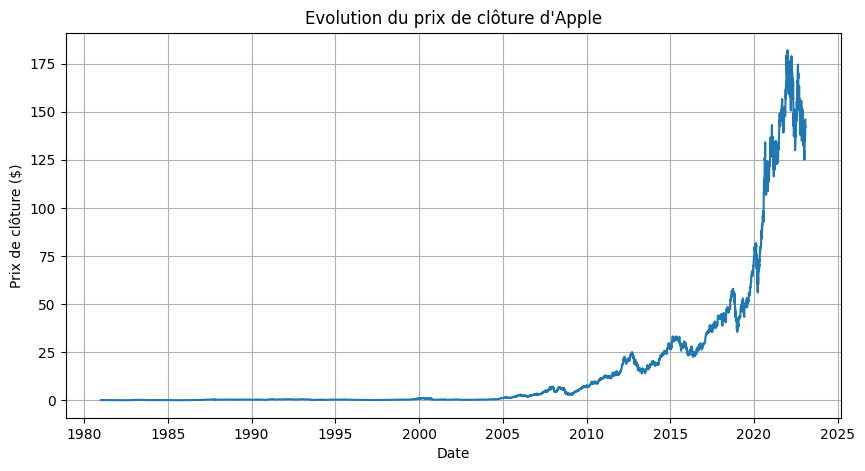

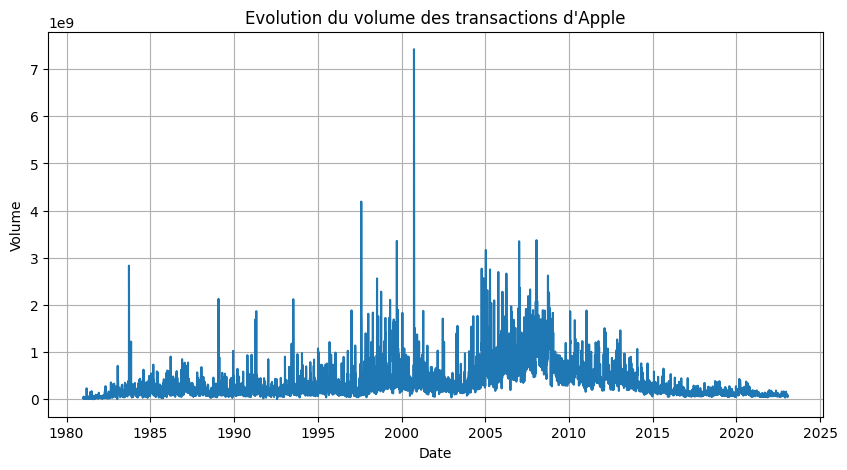

In [9]:
import matplotlib.pyplot as plt

# Graphique du prix de clôture
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"])

plt.title("Evolution du prix de clôture d'Apple")
plt.xlabel("Date")
plt.ylabel("Prix de clôture ($)")
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("Evolution du volume des transactions d'Apple")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

## 3. Analyse statistique

In [ ]:
import pandas as pd

df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

print(df.columns)

for colonne in df.columns:

    # Ignorer la colonne Date
    if colonne != "Date":

        print("Colonne :", colonne)

        # Moyenne
        print("Moyenne")
        print(df[colonne].mean())

        # Médiane
        print("Médiane")
        print(df[colonne].median())

        # Écart-type
        print("Écart-type")
        print(df[colonne].std())


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Colonne : Open
Moyenne
16.689172588518105
Médiane
0.488839
Écart-type
35.45051888348927

Colonne : High
Moyenne
16.879955221342385
Médiane
0.495536
Écart-type
35.882847789120255

Colonne : Low
Moyenne
16.500821578525642
Médiane
0.4804465
Écart-type
35.03128850043325

Colonne : Close
Moyenne
16.69736201451735
Médiane
0.487701
Écart-type
35.47391163938848

Colonne : Adj Close
Moyenne
16.02734531806184
Médiane
0.4048505
Écart-type
35.15487789751425

Colonne : Volume
Moyenne
327509817.26055807
Médiane
214597600.0
Écart-type
337820279.05772686


## 4.Moyenne mobile

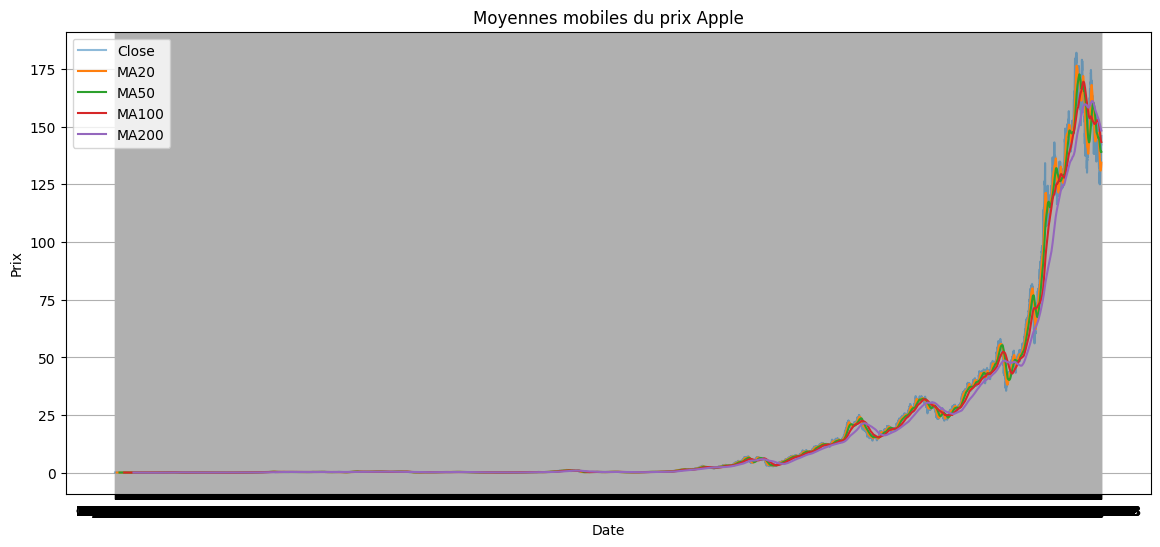

In [21]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA100"] = df["Close"].rolling(window=100).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close", alpha=0.5)
plt.plot(df["Date"], df["MA20"], label="MA20")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.plot(df["Date"], df["MA100"], label="MA100")
plt.plot(df["Date"], df["MA200"], label="MA200")

plt.title("Moyennes mobiles du prix Apple")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)

plt.show()

## 5.Test

In [23]:
from scipy.stats import ttest_ind
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Annee"] = df["Date"].dt.year

close_2021 = df[df["Annee"] == 2021]["Close"]
close_2022 = df[df["Annee"] == 2022]["Close"]

t_stat, p_value = ttest_ind(close_2021, close_2022)

print("Statistique t :", t_stat)
print("p-value :", p_value)

Statistique t : -11.183996762023252
p-value : 4.4812435808098574e-26


## 6. Rendements quotidiens

In [24]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Rendement quotidien
df["Rendement"] = df["Close"].pct_change()

print(df[["Date", "Close", "Rendement"]].head())

gains = df[df["Rendement"] > 0]["Rendement"]
print("Nombre de jours de gain :", len(gains))

pertes = df[df["Rendement"] < 0]["Rendement"]
print("Nombre de jours de perte :", len(pertes))

        Date     Close  Rendement
0 1981-01-02  0.154018        NaN
1 1981-01-05  0.150670  -0.021738
2 1981-01-06  0.143973  -0.044448
3 1981-01-07  0.137835  -0.042633
4 1981-01-08  0.135045  -0.020242
Nombre de jours de gain : 5255
Nombre de jours de perte : 4977


## 7. Test de normalité

In [25]:
from scipy.stats import shapiro

df["Rendement"] = df["Close"].pct_change()

stat, p_value = shapiro(df["Rendement"].dropna())

print("Statistique :", stat)
print("p-value :", p_value)

Statistique : 0.9190583946174027
p-value : 1.7898289463728573e-59


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10607.
  res = hypotest_fun_out(*samples, **kwds)
